## Smart Location Database
-  Google Drive Link: https://drive.google.com/drive/folders/1brJHl3erkNzy_dTF98I82eG5_jvUhwgU?usp=sharing
-  Dataset Link: https://drive.google.com/drive/folders/1Q4iroaiCfD2w1STqbfoIRECa5Z5CT0Eo?usp=sharing
-  Variable Legend:
  https://geodata.epa.gov/arcgis/rest/services/OA/SmartLocationDatabase/MapServer/layers


#### NOTE: Due to GitHub size constraints, the database files cannot be uploaded onto Github. To access the dataset, use the "Google Drive Link" or "Dataset Link" above.

In [1]:
!pip install fiona
!pip install census

import os
import fiona
import geopandas as gpd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math
from census import Census

In [2]:
### ON DRIVE

# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

# Path to your GDB file (update this path)
gdb_path = '/content/drive/MyDrive/Junior/INFO 3130/Final Project/Community - Connie/SLD.gdb'

# Check the layers available in the GDB
layers = fiona.listlayers(gdb_path)

# Read a specific layer (for example, the first one)
layer_name = layers[0]  # you can change this to any layer you want to load
smart_location_df = gpd.read_file(gdb_path, layer=layer_name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
ny_smart_location_df = smart_location_df[smart_location_df['STATEFP'] == '36'].reset_index(drop=True)
ny_smart_location_df.set_index('GEOID20', inplace=True)
ny_smart_location_df.head()

,GEOID10,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,CSA,CSA_Name,CBSA,CBSA_Name,CBSA_POP,...,VMT_per_worker,VMT_tot_min,VMT_tot_max,VMT_tot_avg,GHG_per_worker,Annual_GHG,SLC_score,Shape_Length,Shape_Area,geometry
GEOID20,,,,,,,,,,,,,,,,,,,,,
360150102001,360150102001,36,015,010200,1,236,"Elmira-Corning, NY",21300,"Elmira, NY",85740.0,...,25.382988,7.690275,32.722666,19.519636,22.616242,5880.222946,29.320723,36464.422442,4.192845e+07,"MULTIPOLYGON (((1549562.097 2296224.275, 15495..."
360630243032,360630243032,36,063,024303,2,160,"Buffalo-Cheektowaga-Olean, NY",15380,"Buffalo-Cheektowaga, NY",1131570.0,...,23.194375,7.344131,28.629467,17.468909,20.666189,5373.209019,25.534440,22887.021935,3.415362e+07,"MULTIPOLYGON (((1380986.983 2370657.447, 13809..."
360070143012,360070143012,36,007,014301,2,None,None,13780,"Binghamton, NY",243447.0,...,25.739532,9.909722,32.589187,20.926535,22.933923,5962.820031,30.202013,14968.354915,5.837457e+06,"MULTIPOLYGON (((1629494.517 2293876.766, 16294..."
360810259002,360810259002,36,081,025900,2,408,"New York-Newark, NY-NJ-CT-PA",35620,"New York-Newark-Jersey City, NY-NJ-PA",19318471.0,...,3.184032,1.032142,36.832113,11.177436,2.836972,737.612823,93.989129,1016.744396,6.461912e+04,"MULTIPOLYGON (((1833576.398 2184608.481, 18336..."
360810166002,360810166002,36,081,016600,2,408,"New York-Newark, NY-NJ-CT-PA",35620,"New York-Newark-Jersey City, NY-NJ-PA",19318471.0,...,5.948216,1.032142,36.832113,11.177436,5.299860,1377.963642,86.267939,1485.032311,9.137724e+04,"MULTIPOLYGON (((1842194.593 2179155.182, 18422..."




---



## Sub-Question 1:
### Does higher transit service frequency and job accessibility via transit correlate with reduced car ownership?



#### Literature:
- https://www.sciencedirect.com/science/article/pii/S0739885920301554?via%3Dihub
- https://theclassicjournal.uga.edu/index.php/2024/04/26/car-culture-the-sociological-factor-of-transit/

#### Variables:

* Transit Frequency:
  * D4E: Aggregate frequency of transit service per capita
* Job Accessibility:
  * D5BR: Jobs within 45-minute transit commute, distance decay (walk network travel time, GTFS schedules) weighted
* Car Ownership & Data:
  * AutoOwn0: Number of households in CBG that own zero automobiles
  * AutoOwn1: Number of households in CBG that own one automobile
  * AutoOwn2p: Number of households in CBG that own two or more automobiles




In [4]:
q1_df = ny_smart_location_df[['D4E', 'D5BR', 'AutoOwn0', 'AutoOwn1', 'AutoOwn2p', 'COUNTYFP', 'TRACTCE']]
q1_df.head()

,D4E,D5BR,AutoOwn0,AutoOwn1,AutoOwn2p,COUNTYFP,TRACTCE
GEOID20,,,,,,,
360150102001,-99999.000000,-99999.0,0,30,243,015,010200
360630243032,-99999.000000,-99999.0,27,165,446,063,024303
360070143012,-99999.000000,-99999.0,35,105,151,007,014301
360810259002,0.088678,3530637.0,230,155,20,081,025900
360810166002,0.017647,203212.0,120,203,124,081,016600


In [5]:
## Removing Rows based on Constraints

# Create a boolean mask for each constraint
mask_D4E = q1_df['D4E'] >= 0
mask_D5BR = q1_df['D5BR'] >= 0
mask_AutoOwn0 = q1_df['AutoOwn0'] >= 0
mask_AutoOwn1 = q1_df['AutoOwn1'] >= 0
mask_AutoOwn2p = q1_df['AutoOwn2p'] >= 0

# Combine all masks using logical AND
combined_mask = mask_D4E & mask_D5BR & mask_AutoOwn0 & mask_AutoOwn1 & mask_AutoOwn2p

# Apply the combined mask to filter the DataFrame
filtered_q1_df = q1_df[combined_mask]
filtered_q1_df = filtered_q1_df[filtered_q1_df['COUNTYFP'].isin(['005', '047', '061', '081', '085'])]
filtered_q1_df = filtered_q1_df.groupby(['COUNTYFP', 'TRACTCE']).mean().reset_index()

# Calculate average car ownership per household
filtered_q1_df['Total_Households'] = filtered_q1_df['AutoOwn0'] + filtered_q1_df['AutoOwn1'] + filtered_q1_df['AutoOwn2p']
filtered_q1_df['Avg_Cars'] = (0*filtered_q1_df['AutoOwn0'] + 1*filtered_q1_df['AutoOwn1'] + 2*filtered_q1_df['AutoOwn2p']) / filtered_q1_df['Total_Households']
filtered_q1_df = filtered_q1_df[~filtered_q1_df['Avg_Cars'].isna()]

filtered_q1_df.head()

,COUNTYFP,TRACTCE,D4E,D5BR,AutoOwn0,AutoOwn1,AutoOwn2p,Total_Households,Avg_Cars
1,005,000200,0.013356,369540.00,89.666667,253.000000,100.000000,442.666667,1.023343
2,005,000400,0.022961,250660.75,108.000000,231.000000,151.750000,490.750000,1.089149
3,005,001600,0.033711,876852.25,249.500000,179.750000,66.250000,495.500000,0.630172
4,005,001900,0.098462,1415764.50,149.500000,76.750000,6.000000,232.250000,0.382131
5,005,002000,0.012328,456751.50,354.666667,127.333333,43.166667,525.166667,0.406855


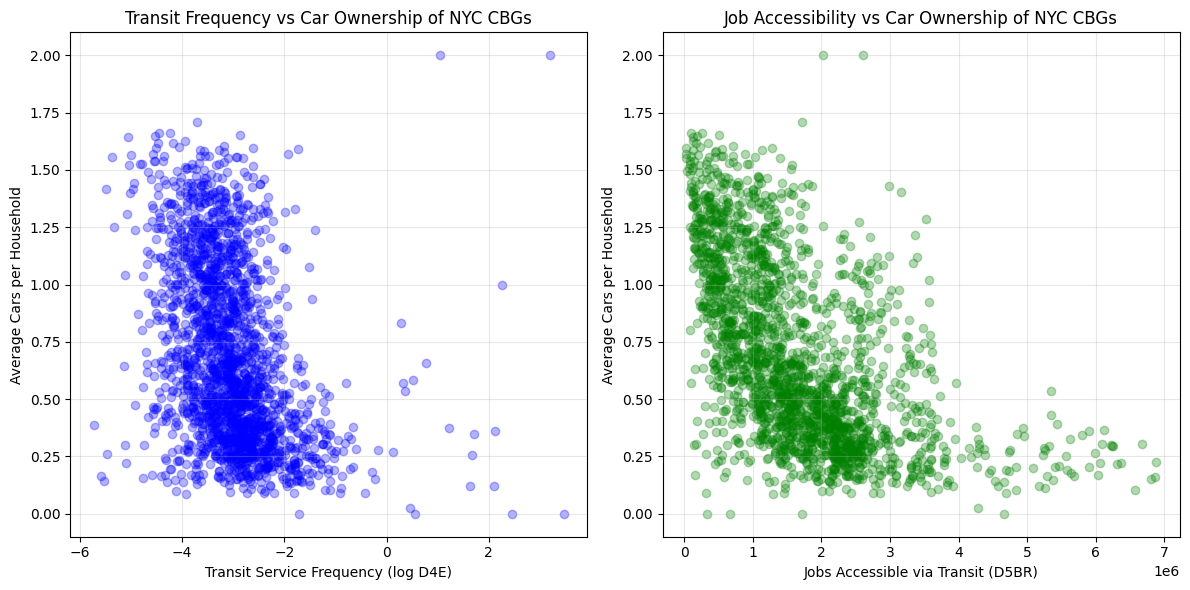

In [6]:
# Create figure
plt.figure(figsize=(12, 6))

# First plot: Transit Frequency vs Car Ownership
plt.subplot(1, 2, 1)
plt.scatter(np.log(filtered_q1_df['D4E']), filtered_q1_df['Avg_Cars'], alpha=0.3, color='blue')
plt.title('Transit Frequency vs Car Ownership of NYC CBGs')
plt.xlabel('Transit Service Frequency (log D4E)')
plt.ylabel('Average Cars per Household')
plt.grid(True, alpha=0.3)

# Second plot: Job Accessibility vs Car Ownership
plt.subplot(1, 2, 2)
plt.scatter(filtered_q1_df['D5BR'], filtered_q1_df['Avg_Cars'], alpha=0.3, color='green')
plt.title('Job Accessibility vs Car Ownership of NYC CBGs')
plt.xlabel('Jobs Accessible via Transit (D5BR)')
plt.ylabel('Average Cars per Household')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



---



## Sub-Question 2:
### Do residents in high income or income-entropy neighborhoods have greater access to jobs via transit (greater number of regional jobs accessible by transit) than those in low income or low-entropy neighborhoods?

#### Literature:
- https://www.richmondfed.org/publications/research/econ_focus/2023/q4_district_digest
- https://cepr.org/voxeu/columns/public-transit-access-and-income-segregation

Variables:


*   Wage:
  * W_P_Lowwage: Percent low wage workers
  * W_P_Medwage: Percent medium wage workers
  * W_P_Highwage: Percent of high wage workers
* Job Accessibility:
  * D5DR: Proportional Accessibility of Regional Destinations by Transit (Employment accessibility expressed as a ratio of total MSA accessibility)


In [7]:
q2_df = ny_smart_location_df[['W_P_Lowwage', 'W_P_Medwage', 'W_P_Highwage', 'D1B','D5DR', 'COUNTYFP', 'TRACTCE']]

# Note to Self: New York County (Not all NYC counties)
q2_df = q2_df[q2_df['COUNTYFP'].isin([ '061'])]
q2_df = q2_df.groupby(['COUNTYFP', 'TRACTCE']).mean().reset_index()
q2_df['GEOID'] = q2_df['COUNTYFP'] + q2_df['TRACTCE']
q2_df.head()

,COUNTYFP,TRACTCE,W_P_Lowwage,W_P_Medwage,W_P_Highwage,D1B,D5DR,GEOID
0,061,000100,0.172688,0.203248,0.623961,0.000000,-99999.000000,061000100
1,061,000201,0.301985,0.254177,0.443803,83.397977,-33332.999807,061000201
2,061,000202,0.153883,0.274033,0.572067,124.218072,-16666.499797,061000202
3,061,000500,0.211697,0.296144,0.492125,0.000000,-33332.999952,061000500
4,061,000600,0.218362,0.216444,0.565179,147.142300,-14285.571165,061000600


In [8]:
## Removing Rows based on Constraints

# Create a boolean mask for each constraint
mask_W_P_Lowwage = (q2_df['W_P_Lowwage'] >= 0) & (q2_df['W_P_Lowwage'] <= 1)
mask_W_P_Medwage = (q2_df['W_P_Medwage'] >= 0) & (q2_df['W_P_Medwage'] <= 1)
mask_W_P_Highwage = (q2_df['W_P_Highwage'] >= 0) & (q2_df['W_P_Highwage'] <= 1)
mask_D5DR = (q2_df['D5DR'] >= 0) & (q2_df['D5DR'] <= 1)

# Combine all masks using logical AND
combined_mask = mask_W_P_Lowwage & mask_W_P_Medwage & mask_W_P_Highwage & mask_D5DR

# Apply the combined mask to filter the DataFrame
filtered_q2_df = q2_df[combined_mask]
filtered_q2_df.head()

,COUNTYFP,TRACTCE,W_P_Lowwage,W_P_Medwage,W_P_Highwage,D1B,D5DR,GEOID
10,061,001200,0.138602,0.343512,0.517887,148.773998,0.000270,061001200
11,061,001300,0.111958,0.164564,0.723479,72.482365,0.000552,061001300
12,061,001401,0.352132,0.392433,0.255436,166.313314,0.000310,061001401
13,061,001402,0.247159,0.354962,0.397879,97.637489,0.000297,061001402
16,061,001600,0.332160,0.328694,0.339146,152.296451,0.000308,061001600


In [9]:
def calculate_entropy_safe(row):
    try:
        # Extract and convert to float
        p_low = float(row['W_P_Lowwage'])
        p_med = float(row['W_P_Medwage'])
        p_high = float(row['W_P_Highwage'])

        # Clip values to avoid zeros
        values = [max(p_low, 1e-10), max(p_med, 1e-10), max(p_high, 1e-10)]

        # Calculate entropy
        total = sum(values)
        normalized = [v/total for v in values]
        return -sum(p * math.log(p) for p in normalized)

    except (ValueError, TypeError) as e:
        print(f"Error processing row {row.name}: {e}")
        return np.nan

filtered_q2_df['wage_entropy'] = filtered_q2_df.apply(calculate_entropy_safe, axis=1)
filtered_q2_df.head()

<ipython-input-9-8c7afb3c6b64>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_q2_df['wage_entropy'] = filtered_q2_df.apply(calculate_entropy_safe, axis=1)


,COUNTYFP,TRACTCE,W_P_Lowwage,W_P_Medwage,W_P_Highwage,D1B,D5DR,GEOID,wage_entropy
10,061,001200,0.138602,0.343512,0.517887,148.773998,0.000270,061001200,0.981721
11,061,001300,0.111958,0.164564,0.723479,72.482365,0.000552,061001300,0.776273
12,061,001401,0.352132,0.392433,0.255436,166.313314,0.000310,061001401,1.083230
13,061,001402,0.247159,0.354962,0.397879,97.637489,0.000297,061001402,1.079798
16,061,001600,0.332160,0.328694,0.339146,152.296451,0.000308,061001600,1.098527


In [10]:
# Aggregate Household Income From ACS
c = Census("")

data = c.acs5.get((
    'B19062_001E'       # Aggregate Yearly Wage for HHs
    ),
    {'for': 'tract:*', 'in': 'state:36 county:061'})

wage_df = pd.DataFrame(data)
wage_df['GEOID'] = wage_df['county'] + wage_df['tract']
wage_df = wage_df[wage_df['B19062_001E'] >= 0]
wage_df.rename(columns={'B19062_001E': 'Aggregate_Wage'}, inplace=True)
wage_df.head()

,Aggregate_Wage,state,county,tract,GEOID
1,2.702720e+07,36,061,000201,061000201
2,1.338169e+08,36,061,000202,061000202
4,2.410649e+08,36,061,000600,061000600
5,1.270135e+09,36,061,000700,061000700
6,2.318262e+08,36,061,000800,061000800


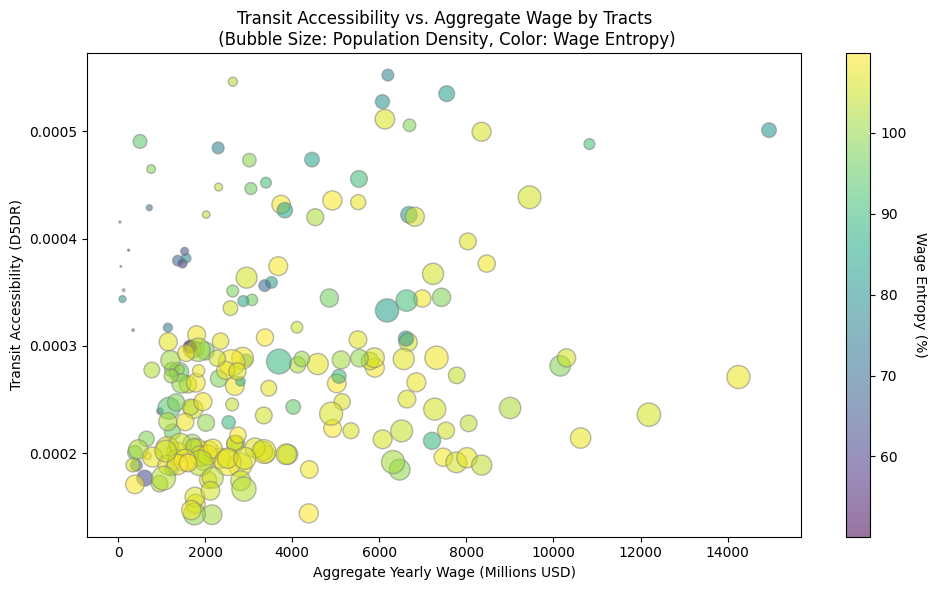

In [11]:
df_plot = filtered_q2_df.merge(
    wage_df[['GEOID', 'Aggregate_Wage']],
    on='GEOID',
    how='inner'
)

# Create figure
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    x=df_plot['Aggregate_Wage']/1e5,
    y=df_plot['D5DR'],
    s=df_plot['D1B'],
    alpha=0.55,
    c=df_plot['wage_entropy'] * 100,
    cmap='viridis',
    edgecolor='gray',
    linewidth=1
)

# Add labels and title
plt.xlabel('Aggregate Yearly Wage (Millions USD)')
plt.ylabel('Transit Accessibility (D5DR)')
plt.title('Transit Accessibility vs. Aggregate Wage by Tracts\n (Bubble Size: Population Density, Color: Wage Entropy)')

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Wage Entropy (%)', rotation=270, labelpad=15)


plt.tight_layout()
plt.show()